In [17]:
import warnings
import logging
import os

# 1. 忽略 Python 一般警告訊息 (如 Pandas 的 SettingWithCopyWarning)
warnings.filterwarnings('ignore')

# 2. 忽略特定模組的警告 
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 3. 減少底層系統的警告輸出
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 設定中文與顯示選項 (整合在一起)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)

In [18]:
# 1. 選取本專案的核心變數
# Q6: CurrentCigaretteUse (群體變數), BMIPCT (反應變數)
target_cols = ['CurrentCigaretteUse', 'BMIPCT']
df_subset = df_raw[target_cols]

# 2. 檢查清理前的遺失值數量
print("【清理前各欄位遺失值統計】")
print(df_subset.isnull().sum())

# 3. 移除包含遺失值 (NaN) 的列，確保分析樣本的完整性
df_clean = df_subset.dropna().copy()

print("-" * 30)
print(f"原始筆數: {len(df_raw)}")
print(f"移除遺失值後的有效筆數: {len(df_clean)}")

【清理前各欄位遺失值統計】
CurrentCigaretteUse    718
BMIPCT                 979
dtype: int64
------------------------------
原始筆數: 14041
移除遺失值後的有效筆數: 12437


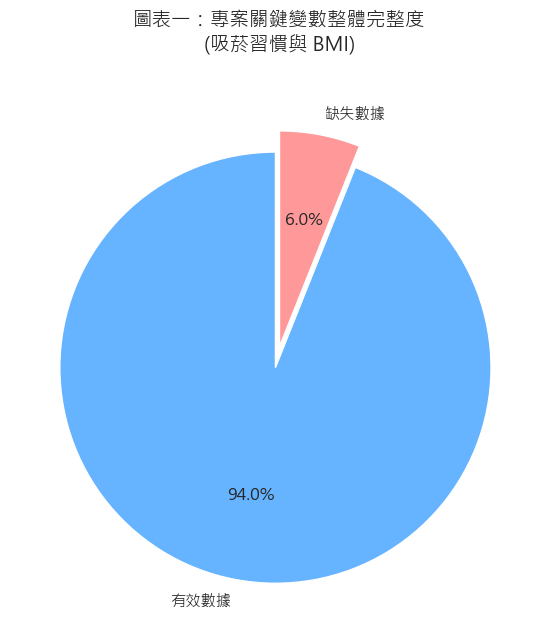

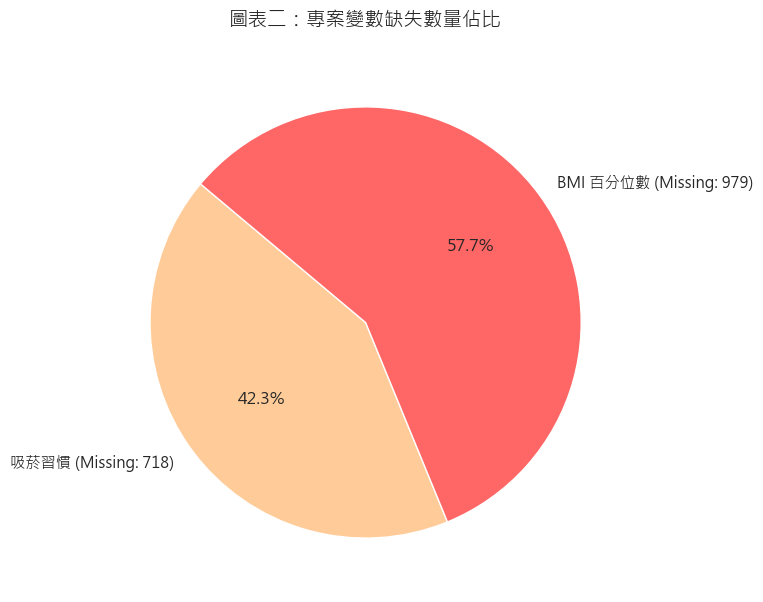

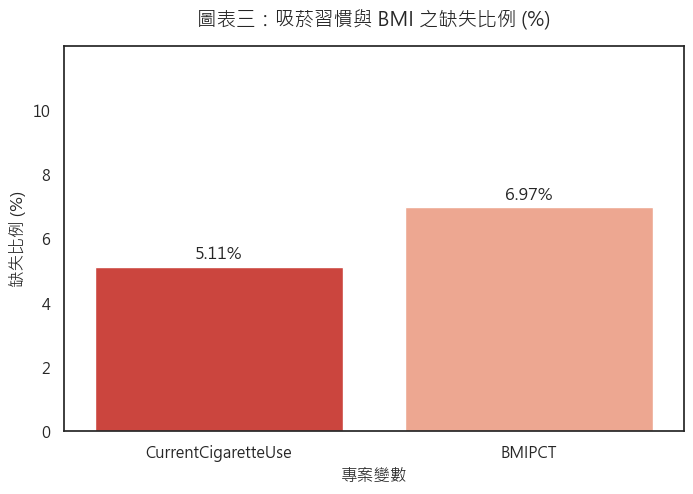

In [19]:

# --- 1. 定義專案核心變數 ---
target_cols = ['CurrentCigaretteUse', 'BMIPCT']
df_target = df_raw[target_cols]

# --- 2. 計算專案變數的缺失統計 ---
missing_counts = df_target.isnull().sum()
missing_pct = (missing_counts / len(df_target)) * 100
missing_report = pd.DataFrame({'缺失比例 (%)': missing_pct})

# --- 繪圖區塊：產出專案專屬圖表並存入變數 ---

# --- 圖表一：專案變數整體數據完整度 (Pie Chart) ---
# 統計這兩個欄位中，總共有多少個 Cell 是遺失的
total_target_cells = df_target.size
null_target_cells = missing_counts.sum()
filled_target_cells = total_target_cells - null_target_cells

plt.figure(figsize=(7, 7))
plt.pie([filled_target_cells, null_target_cells], 
        labels=['有效數據', '缺失數據'], 
        autopct='%1.1f%%', 
        colors=['#66b3ff','#ff9999'], 
        startangle=90, 
        explode=(0.1, 0))
plt.title('圖表一：專案關鍵變數整體完整度\n(吸菸習慣與 BMI)', fontsize=14, pad=20)
fig1 = plt.gcf()

# --- 圖表二：變數間缺失比例比較 (Pie Chart) ---
# 目的：觀察吸菸欄位與 BMI 欄位，哪一個遺失的情況較嚴重
plt.figure(figsize=(7, 7))
plt.pie(missing_counts, 
        labels=[f'吸菸習慣 (Missing: {missing_counts[0]})', 
                f'BMI 百分位數 (Missing: {missing_counts[1]})'], 
        autopct='%1.1f%%', 
        colors=['#ffcc99','#ff6666'], 
        startangle=140)
plt.title('圖表二：專案變數缺失數量佔比', fontsize=14, pad=20)
fig2 = plt.gcf()

# --- 圖表三：各變數缺失比例長條圖 (Bar Chart) ---
# 目的：精確呈現這兩個關鍵變數的缺失百分比
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=missing_report.index, y='缺失比例 (%)', data=missing_report, palette='Reds_r')
plt.title('圖表三：吸菸習慣與 BMI 之缺失比例 (%)', fontsize=14, pad=15)
plt.ylabel('缺失比例 (%)', fontsize=12)
plt.xlabel('專案變數', fontsize=12)
plt.ylim(0, max(missing_pct) + 5) # 自動調整 Y 軸高度並留白

# 在柱狀圖上方顯示數值標籤
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

fig3 = plt.gcf()

In [20]:
import os

# 1. 定義儲存路徑 (依照 Cookiecutter 結構，通常存放在 outputs/figures/)
output_dir = '../outputs/figures/'

# 2. 如果資料夾不存在，則自動建立
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"已建立資料夾: {output_dir}")

# 3. 儲存圖表
# dpi=300 代表高解析度，bbox_inches='tight' 確保標籤不會被切到
fig1.savefig(os.path.join(output_dir, '01_data_integrity_pie.png'), dpi=300, bbox_inches='tight')
fig2.savefig(os.path.join(output_dir, '01_missing_distribution_pie.png'), dpi=300, bbox_inches='tight')
fig3.savefig(os.path.join(output_dir, '01_target_missing_bar.png'), dpi=300, bbox_inches='tight')

print("-" * 30)
print(f"成功儲存 3 張圖表至: {output_dir}")
print("1. 01_data_integrity_pie.png (專案完整度圓餅圖)")
print("2. 01_missing_distribution_pie.png (缺失數量佔比圖)")
print("3. 01_target_missing_bar.png (缺失比例長條圖)")

# 最後顯示圖表（可選）
plt.show()

------------------------------
成功儲存 3 張圖表至: ../outputs/figures/
1. 01_data_integrity_pie.png (專案完整度圓餅圖)
2. 01_missing_distribution_pie.png (缺失數量佔比圖)
3. 01_target_missing_bar.png (缺失比例長條圖)


In [21]:
# 1. 篩選核心變數並移除缺失值 (Drop missing values)
target_cols = ['CurrentCigaretteUse', 'BMIPCT']
df_clean = df_raw[target_cols].dropna()

# 2. 進行重編碼 (1 -> 0 不吸菸, 2-7 -> 1 有吸菸)
# 這樣在 EDA 與統計推論時才有二元對照組
df_clean['Smoking_Status'] = df_clean['CurrentCigaretteUse'].apply(lambda x: 0 if x == 1 else 1)

# 3. 儲存成「清理後」的 CSV
# 檔案會存在 data/processed/ 資料夾下
processed_path = '../data/processed/cleaned_cycle3.csv'
df_clean.to_csv(processed_path, index=False, encoding='utf-8-sig')

print(f"✅ 資料清理成功！")
print(f"有效樣本數 (排除缺失值後)：{len(df_clean)} 筆")
print(f"檔案已儲存至：{processed_path}")

✅ 資料清理成功！
有效樣本數 (排除缺失值後)：12437 筆
檔案已儲存至：../data/processed/cleaned_cycle3.csv
